# `hgv` — Object-Centric Event Log Visualization

Comparing the **flat** and **full** representations of the coffeehouse process log.

**Reading the chart:**
- Each **row** is one object, shaded by its type.
- Each **vertical line** is an event at its timestamp, colored by its type.
- **Circles** on a row mark that object's participation in the event.
- A vertical line spans exactly the objects involved — this is the hyperedge.

**Connected components:** the log contains two independent process instances.
Component 1 (B1, two orders) spans the full time window; Component 2 (B2, one
order with two drinks) is temporally *engulfed* by Component 1, illustrating
why naive flattening to a single object type conflates unrelated cases.

In [1]:
import sys
sys.path.insert(0, "..")

import json
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from hgv import parse, render, make_color_dicts, draw_legend, flatten_to_object_type
from hgv.transform import connected_components, flatten

%matplotlib inline

plt.rcParams.update({
    "font.family":           "sans-serif",
    "font.size":             8,
    "legend.fontsize":       7,
    "legend.title_fontsize": 7.5,
    "figure.dpi":            200,
})

In [2]:
with open("coffeehouse_process.json") as f:
    data = json.load(f)

full_log   = parse(data)
flat_log   = flatten_to_object_type(full_log, "Order")
components = connected_components(full_log)

comp1, comp2 = components[0], components[1]

# Global time range — all plots share the same x-axis span
_all_times  = [e.time for e in full_log.events]
GLOBAL_TMIN = min(_all_times)
GLOBAL_TMAX = max(_all_times)
TIME_RANGE  = (GLOBAL_TMIN, GLOBAL_TMAX)

print(f"Full log    : {len(full_log.objects)} objects, {len(full_log.events)} events")
print(f"Flat log    : {len(flat_log.objects)} objects (order only), {len(flat_log.events)} events")
print(f"Component 1 : {len(comp1.objects)} objects, {len(comp1.events)} events  [{min(e.time for e in comp1.events)} – {max(e.time for e in comp1.events)}]")
print(f"Component 2 : {len(comp2.objects)} objects, {len(comp2.events)} events  [{min(e.time for e in comp2.events)} – {max(e.time for e in comp2.events)}]")
print(f"Global span : {GLOBAL_TMIN} – {GLOBAL_TMAX}")

Full log    : 12 objects, 22 events
Flat log    : 3 objects (order only), 19 events
Component 1 : 7 objects, 13 events  [2024-01-15 08:00:00+00:00 – 2024-01-15 08:18:00+00:00]
Component 2 : 5 objects, 9 events  [2024-01-15 08:07:00+00:00 – 2024-01-15 08:15:00+00:00]
Global span : 2024-01-15 08:00:00+00:00 – 2024-01-15 08:18:00+00:00


## Flat vs Full — stacked comparison

Flat log (top) and full log (bottom) aligned on the same time axis,
one textwidth wide. Saved to `flat_vs_full.pdf`.

In [3]:
# ── Figure parameters ────────────────────────────────────────────────────────
TEXT_W   = 8.27   # 65 % of A4 width
ROW_H    = 0.2           # inches per object row
MARGINS  = 0.3      # top + bottom axis margins
LEGEND_W = 1.8            # legend column width (same for both boxes)

_LEG_BASE = dict(
    mode="expand",
    loc="upper left",
    fontsize=7,
    title_fontsize=7.5,
    framealpha=0.9,
    edgecolor="#cccccc",
    handlelength=1.5,
    handletextpad=0.4,
    borderpad=0.6,
)

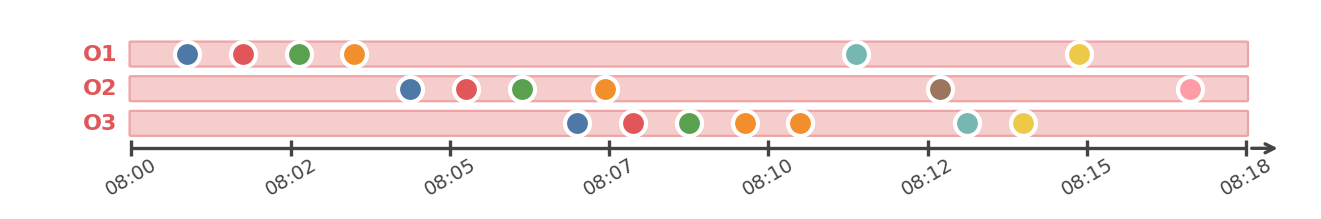

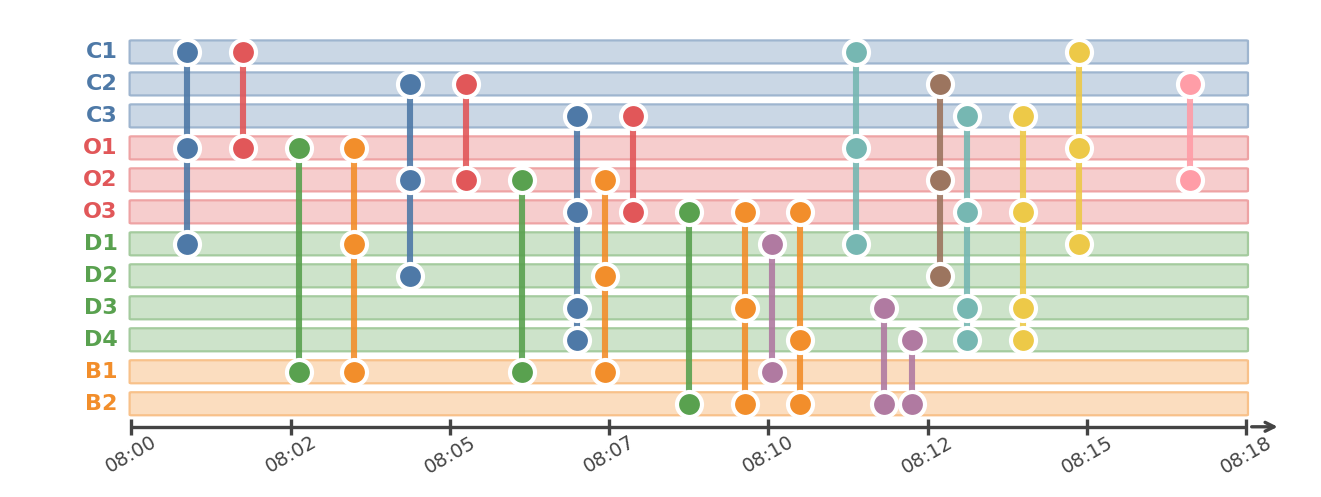

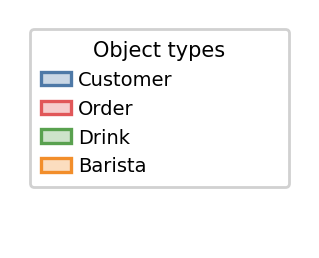

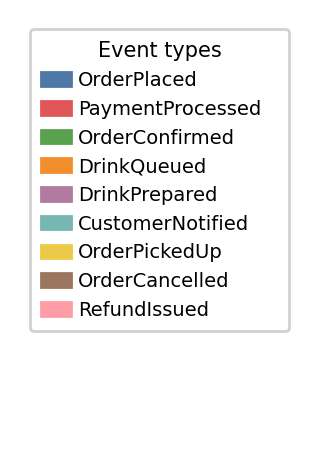

In [4]:
import matplotlib.patches as mpatches
from hgv.viz import _lighten

obj_color, evt_color = make_color_dicts(full_log)

obj_handles = [
    mpatches.Patch(facecolor=_lighten(obj_color[t], 0.30),
                   edgecolor=obj_color[t], linewidth=1.2, label=t)
    for t in full_log.object_types if t in obj_color
]
evt_handles = [
    mpatches.Patch(color=evt_color[t], label=t)
    for t in full_log.event_types if t in evt_color
]

def make_fig(log, filename):
    panel_h = len(log.objects) * ROW_H + MARGINS
    fig = plt.figure(figsize=(TEXT_W, panel_h))
    ax = fig.add_subplot(111)
    render(log, ax=ax, row_height=ROW_H,
           obj_color=obj_color, evt_color=evt_color,
           time_range=TIME_RANGE)
    fig.savefig(filename, bbox_inches="tight")
    plt.show()

def make_legend_fig(handles, title, filename):
    n = len(handles)
    fig, ax = plt.subplots(figsize=(LEGEND_W, n * 0.28 + 0.3))
    ax.axis("off")
    ax.legend(handles=handles, title=title,
              bbox_to_anchor=(0, 0, 1, 1),
              bbox_transform=ax.transAxes,
              **_LEG_BASE)
    fig.savefig(filename, bbox_inches="tight")
    plt.show()

make_fig(flat_log, filename="flat_log_order.pdf")
make_fig(full_log, filename="full_log.pdf")

make_legend_fig(obj_handles, "Object types", "legend_objects.pdf")
make_legend_fig(evt_handles, "Event types",  "legend_events.pdf")

## Connected components

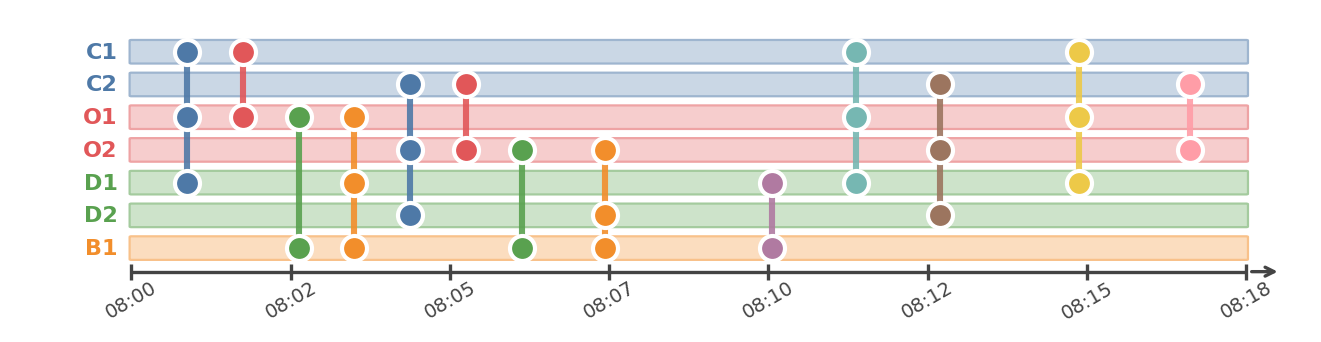

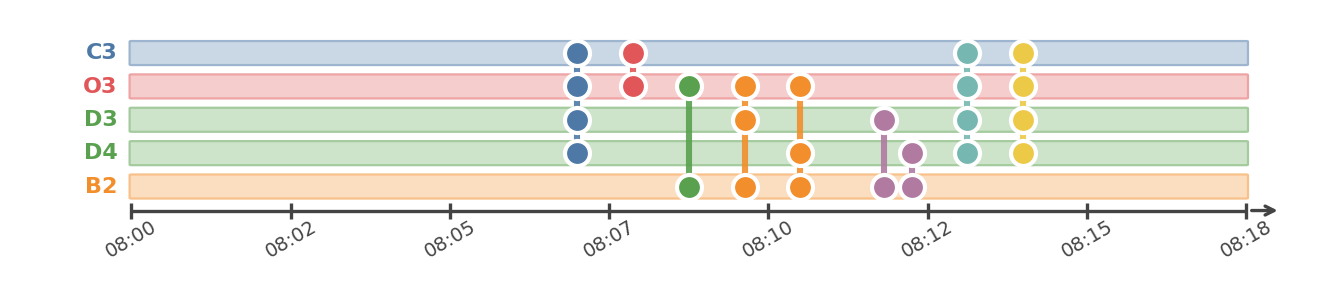

In [5]:
make_fig(comp1, filename="component_1.pdf")
make_fig(comp2, filename="component_2.pdf")